# 영상을 10초 단위로 gif로 변환하여 보여줌
- 네트워크 볼륨에서는 영상 확인이 안됨
- 모두 다운로드해서 확인하기에는 용량이 너무 큼
- 바로 볼 수 있도록 1

✅ 영상 총 길이: 180초
🚀 GIF 생성 및 로딩 시작 (10초 단위)...


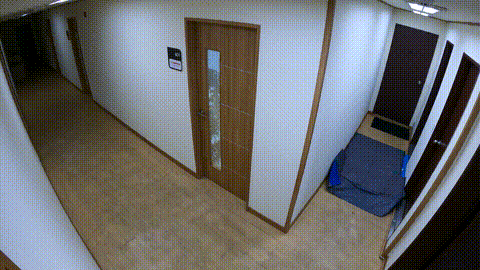

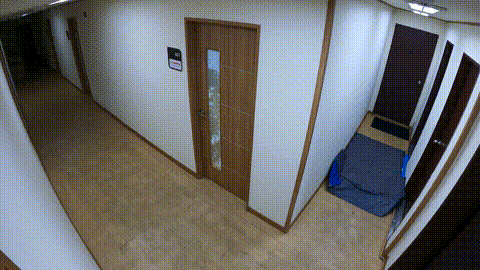

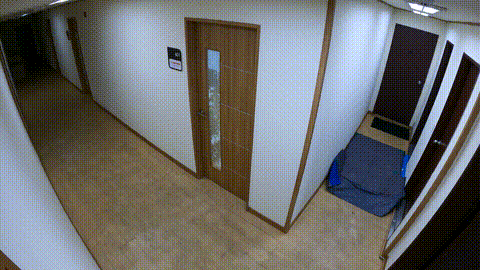

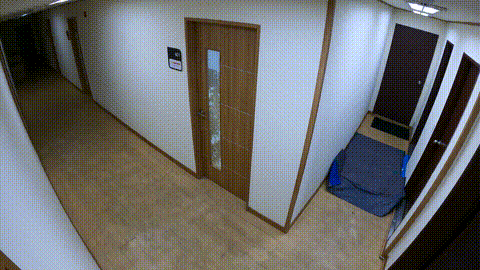

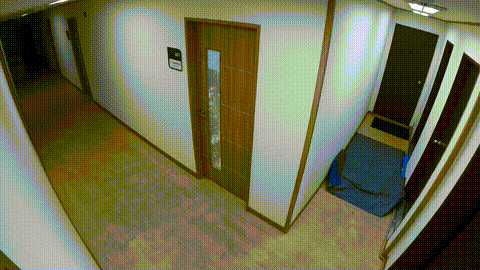

...

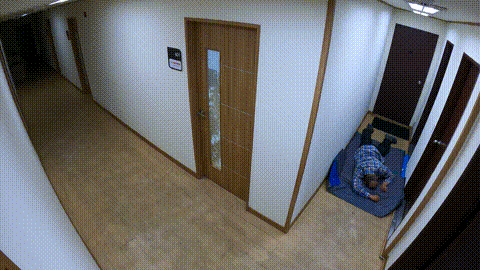

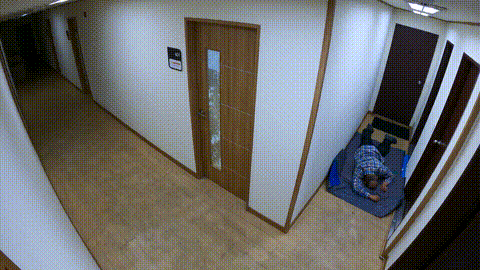

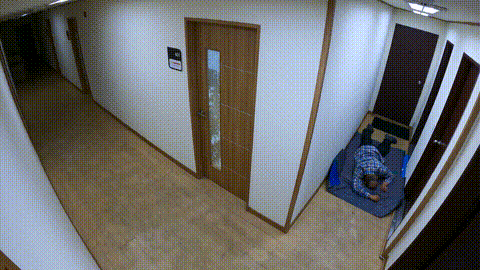

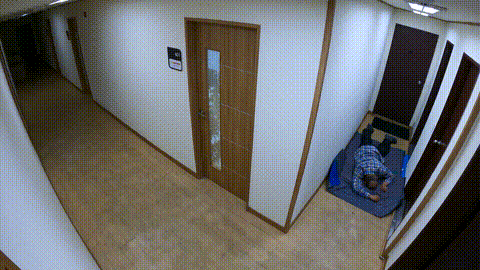

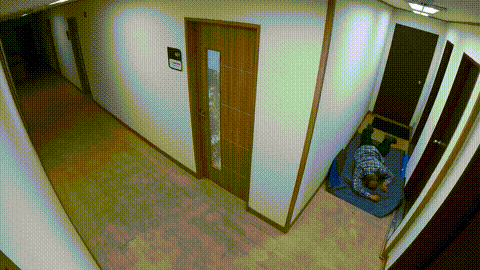

✨ 모든 구간의 확인이 완료되었습니다.


In [1]:
import os
import subprocess
from IPython.display import Image, display, HTML

# 1. 경로 설정
VIDEO_PATH = "/workspace/data/video/ai_hub_senior_anomaly/Validation/video/Abnormal_Behavior_Falldown/video_frames/H11H21H31/FD_In_H11H21H31_0009_20201229_14.mp4"
OUTPUT_DIR = "/workspace/members/kim/0505_gif_check_1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 2. 영상 전체 길이(Duration) 가져오기
ffprobe_cmd = [
    "ffprobe", "-v", "error", "-show_entries", "format=duration",
    "-of", "default=noprint_wrappers=1:nokey=1", VIDEO_PATH
]
duration = float(subprocess.check_output(ffprobe_cmd).decode().strip())
duration_int = int(duration)

print(f"✅ 영상 총 길이: {duration_int}초")
print(f"🚀 GIF 생성 및 로딩 시작 (10초 단위)...")

# 3. 10초 단위로 루프 돌며 생성 및 즉시 출력
for start in range(0, duration_int, 10):
    output_file = os.path.join(OUTPUT_DIR, f"chunk_{start:03d}s.gif")
    
    # ffmpeg 실행 (기존 파일이 있으면 -y로 덮어쓰기)
    ffmpeg_cmd = [
        "ffmpeg", "-y", "-ss", str(start), "-t", "10", 
        "-i", VIDEO_PATH, 
        "-vf", "scale=480:-1,fps=10", # 용량을 위해 해상도와 fps 조절
        output_file
    ]
    
    # 쉘 명령 실행 (출력은 숨김)
    subprocess.run(ffmpeg_cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    
    # 4. 화면에 즉시 출력
    display(HTML(f"<h3 style='color: #2e7d32;'>📍 구간: {start}s ~ {min(start+10, duration_int)}s</h3>"))
    if os.path.exists(output_file):
        display(Image(filename=output_file))
    display(HTML("<hr>"))

print("✨ 모든 구간의 확인이 완료되었습니다.")